**Classify Quasar against Galaxies**

In [1]:
import pandas as pd
df_gq = pd.read_csv("galaxyquasar.csv")
df_gq

,u,g,r,i,z,class,z1,zerr
0,18.97213,18.53676,18.58280,18.34936,18.29215,QSO,0.522819,0.000155
1,19.24592,17.47646,16.47817,16.04472,15.68851,GALAXY,0.122846,0.000028
2,19.43536,17.70268,16.91565,16.58327,16.39128,GALAXY,0.000000,0.000000
3,19.31626,18.18312,17.39591,16.94549,16.65395,GALAXY,0.147435,0.000009
4,19.28828,19.11188,18.88937,18.80013,18.49183,QSO,2.011455,0.000631
...,...,...,...,...,...,...,...,...
49995,19.37295,18.12382,17.39886,16.98503,16.70585,GALAXY,0.113016,0.000011
49996,18.52021,16.88262,16.03280,15.56884,15.22454,GALAXY,0.085063,0.000014
49997,18.62718,17.30876,16.87371,16.62399,16.42296,GALAXY,0.054429,0.000008
49998,19.55140,18.27711,17.62101,17.21947,17.03347,GALAXY,0.112571,0.000009


In [2]:
ug = df_gq.get("u") - df_gq.get("g")
gr = df_gq.get("g") - df_gq.get("r")
ri = df_gq.get("r") - df_gq.get("i")
iz = df_gq.get("i") - df_gq.get("z")
class_list = []
for i in range(len(df_gq)):
    if df_gq.get("class")[i] == "GALAXY":
        class_list.append(0)
    else:
        class_list.append(1)

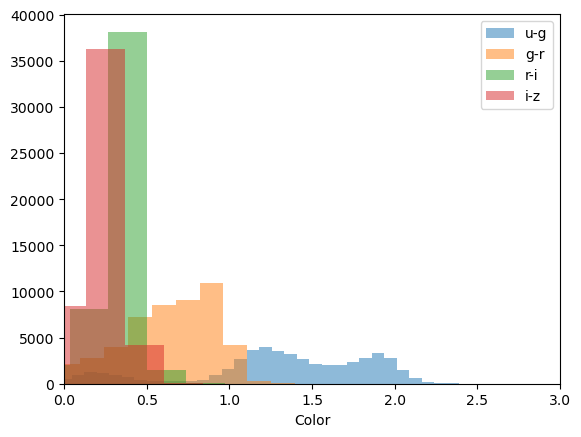

In [3]:
import matplotlib.pyplot as plt

plt.hist(ug, bins=100, alpha=0.5, label='u-g', color='C0')
plt.hist(gr, bins=100, alpha=0.5, label='g-r', color='C1')
plt.hist(ri, bins=100, alpha=0.5, label='r-i', color='C2')
plt.hist(iz, bins=100, alpha=0.5, label='i-z', color='C3')
plt.xlim(0, 3)
plt.xlabel("Color")
plt.legend()
plt.show()

Probably the two pic in "ug" is informative of a distintion beetween Galaxy and quasar.

In [4]:
from sklearn.model_selection import train_test_split
import numpy as np

X = np.array(ug).reshape(-1, 1)
Y = class_list

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)


In [5]:
# Naive Bayes Classifier

from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split

gnb = GaussianNB()

gnb.fit(X_train, y_train)
print("Train set score Naive Bayes: ", gnb.score(X_train, y_train))
print("Test set score Naive Bayes: ", gnb.score(X_test, y_test))

Train set score Naive Bayes:  0.9814
Test set score Naive Bayes:  0.9794


In [6]:
# LDA&QDA Classifier

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
qda = QuadraticDiscriminantAnalysis()

lda.fit(X_train, y_train)
qda.fit(X_train, y_train)

print("Train set score (LDA): ", lda.score(X_train, y_train))
print("Test set score (LDA): ", lda.score(X_test, y_test))
print("Train set score (QDA): ", qda.score(X_train, y_train))
print("Test set score (QDA): ", qda.score(X_test, y_test))

Train set score (LDA):  0.981225
Test set score (LDA):  0.9795
Train set score (QDA):  0.9814
Test set score (QDA):  0.9794


In [ ]:
# K-Nearest Neighbors Classifier

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=9) # Check for the best k value
knn.fit(X_train, y_train)
print("Train set score K-Nearest Neighbors: ", knn.score(X_train, y_train))
print("Test set score K-Nearest Neighbors: ", knn.score(X_test, y_test))

Train set score K-Nearest Neighbors:  0.98265
Test set score K-Nearest Neighbors:  0.9784


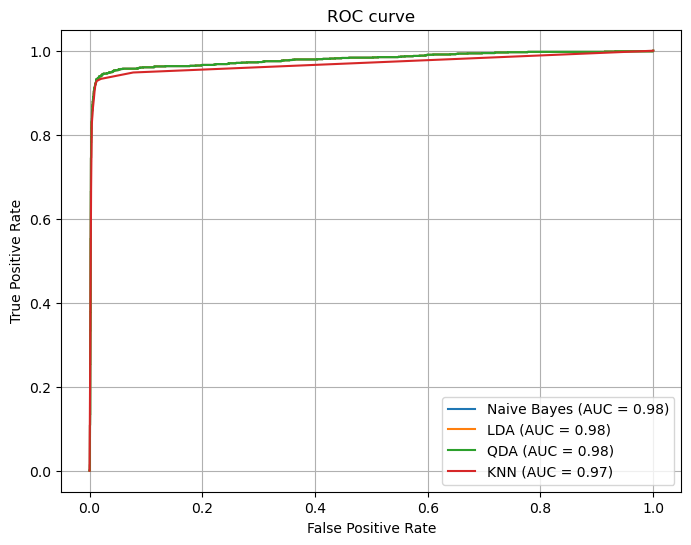

In [12]:
from sklearn.metrics import roc_curve, auc

labels = ["Naive Bayes", "LDA", "QDA", "KNN"]

y_score = [None] * 4
y_score[0] = gnb.predict_proba(X_test)[:, 1]
y_score[1] = lda.predict_proba(X_test)[:, 1]
y_score[2] = qda.predict_proba(X_test)[:, 1]
y_score[3] = knn.predict_proba(X_test)[:, 1]

plt.figure(figsize=(8, 6))
for i in range(4): 
    plt.plot(*roc_curve(y_test, y_score[i])[:2], label=f"{labels[i]} (AUC = {auc(*roc_curve(y_test, y_score[i])[:2]):.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve")
plt.legend(loc="lower right")
plt.grid()
plt.show()